In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

# ---------------------------------------------------------
# 1. Definitive Vectorized DFOULS Model
# ---------------------------------------------------------
class DFOULS_Definitive(nn.Module):
    def __init__(self, obs_dim, latent_dim, covar_dim, delta=1e-4, theta_mode="diagonal"):
        super().__init__()
        self.D = obs_dim
        self.K = latent_dim
        self.C_dim = covar_dim
        self.delta = delta
        self.theta_mode = theta_mode
        
        # 1. Continuous-Time Dynamics
        if self.theta_mode == "dense":
            self.L = nn.Parameter(torch.eye(self.K) + 0.1 * torch.randn(self.K, self.K))
            self.K_unconstrained = nn.Parameter(torch.randn(self.K, self.K) * 0.1)
        elif self.theta_mode == "diagonal":
            self.log_rho = nn.Parameter(torch.randn(self.K) * 0.1 - 2.0)
            
        # 2. Linear Mean Function
        self.B = nn.Parameter(torch.randn(self.K, self.C_dim) * 0.1)
        self.C_int = nn.Parameter(torch.randn(self.K, self.C_dim) * 0.1)
        self.d_bias = nn.Parameter(torch.randn(self.K) * 0.1)
        
        # 3. Factor Loadings (Reverted to nn.Parameter for gentle GEM optimization)
        self.Z = nn.Parameter(torch.randn(self.D, self.K) - 0.5) 
        self.register_buffer('tril_mask', torch.tril(torch.ones(self.D, self.K)))

    def get_theta(self):
        if self.theta_mode == "dense":
            L_tril = torch.tril(self.L)
            S = L_tril @ L_tril.T + self.delta * torch.eye(self.K, device=self.Z.device)
            return S + (self.K_unconstrained - self.K_unconstrained.T)
        return torch.diag(torch.exp(self.log_rho))

    def get_subject_matrices(self, Theta, u, times):
        dt = times[1:] - times[:-1]
        Theta_batch = Theta.unsqueeze(0).expand(times.shape[0]-1, self.K, self.K)
        A_trans = torch.linalg.matrix_exp(-Theta_batch * dt.view(-1, 1, 1))
        
        u_t, t_val = u[1:], times[1:].unsqueeze(1)
        mu = u_t @ self.B.T + (u_t * t_val) @ self.C_int.T + self.d_bias
        
        I_batch = torch.eye(self.K, device=self.Z.device).unsqueeze(0).expand(times.shape[0]-1, self.K, self.K)
        b_shift = torch.bmm(I_batch - A_trans, mu.unsqueeze(-1)).squeeze(-1)
        
        Lambda = self.tril_mask * torch.exp(self.Z)
        return A_trans, b_shift, dt, Lambda

    def kalman_smoother(self, x_obs, A_trans, b_shift, dt, Lambda):
        T = x_obs.shape[0]
        device = x_obs.device
        
        f_pred, P_pred = torch.zeros(T, self.K, device=device), torch.zeros(T, self.K, self.K, device=device)
        f_filt, P_filt = torch.zeros(T, self.K, device=device), torch.zeros(T, self.K, self.K, device=device)
        f_filt[0], P_filt[0] = torch.zeros(self.K, device=device), torch.eye(self.K, device=device)
        
        R_mat, I_k = torch.eye(self.D, device=device), torch.eye(self.K, device=device)
        
        for j in range(1, T):
            idx = j - 1
            f_pred[j] = A_trans[idx] @ f_filt[j-1] + b_shift[idx]
            P_pred[j] = A_trans[idx] @ P_filt[j-1] @ A_trans[idx].T + (dt[idx] * I_k)
            
            if torch.isnan(x_obs[j]).all():
                f_filt[j], P_filt[j] = f_pred[j], P_pred[j]
            else:
                x_pred = Lambda @ f_pred[j]
                S_t = Lambda @ P_pred[j] @ Lambda.T + R_mat
                K_gain = P_pred[j] @ Lambda.T @ torch.linalg.inv(S_t)
                f_filt[j] = f_pred[j] + K_gain @ (x_obs[j] - x_pred)
                P_filt[j] = (I_k - K_gain @ Lambda) @ P_pred[j]
            
        f_smooth, P_smooth, P_cross = torch.zeros_like(f_filt), torch.zeros_like(P_filt), torch.zeros_like(P_filt)
        f_smooth[-1], P_smooth[-1] = f_filt[-1], P_filt[-1]
        
        for j in range(T-2, -1, -1):
            J_t = P_filt[j] @ A_trans[j].T @ torch.linalg.inv(P_pred[j+1])
            f_smooth[j] = f_filt[j] + J_t @ (f_smooth[j+1] - f_pred[j+1])
            P_smooth[j] = P_filt[j] + J_t @ (P_smooth[j+1] - P_pred[j+1]) @ J_t.T
            P_cross[j+1] = J_t @ P_smooth[j+1]
            
        return f_smooth, P_smooth, P_cross

    def expected_complete_log_posterior_vectorized(self, subjects_data, smoothed_stats, Theta, Lambda):
        ll_obs, ll_lat = 0.0, 0.0
        LTL = Lambda.T @ Lambda 
        
        for i, subj in enumerate(subjects_data):
            x_obs, u, times = subj['x'], subj['u'], subj['t']
            f_s, P_s, P_c = smoothed_stats[i]
            A_trans, b_shift, dt, _ = self.get_subject_matrices(Theta, u, times)
            
            valid_mask = ~torch.isnan(x_obs).any(dim=1)
            if valid_mask.any():
                x_v, f_v, P_v = x_obs[valid_mask], f_s[valid_mask], P_s[valid_mask]
                trace_E = torch.sum(P_v * LTL, dim=(1,2)) + torch.sum(f_v * (f_v @ LTL), dim=1)
                term_obs = torch.sum(x_v**2, dim=1) - 2 * torch.sum(x_v * (f_v @ Lambda.T), dim=1) + trace_E
                ll_obs -= 0.5 * torch.sum(term_obs)
                
            f_j, f_jm1 = f_s[1:], f_s[:-1]
            P_j, P_jm1, P_cj = P_s[1:], P_s[:-1], P_c[1:]
            
            trace_Ej = torch.diagonal(P_j, dim1=-2, dim2=-1).sum(-1) + torch.sum(f_j**2, dim=1)
            AtA = torch.bmm(A_trans.transpose(1, 2), A_trans)
            trace_AEjm1A = torch.sum(P_jm1 * AtA, dim=(1,2)) + torch.sum(f_jm1 * torch.bmm(AtA, f_jm1.unsqueeze(-1)).squeeze(-1), dim=1)
            bb = torch.sum(b_shift**2, dim=1)
            
            trace_AEcross = torch.sum(P_cj * A_trans, dim=(1,2)) + torch.sum(f_j * torch.bmm(A_trans, f_jm1.unsqueeze(-1)).squeeze(-1), dim=1)
            b_f = torch.sum(b_shift * f_j, dim=1)
            A_fm1 = torch.bmm(A_trans, f_jm1.unsqueeze(-1)).squeeze(-1)
            b_A_fm1 = torch.sum(b_shift * A_fm1, dim=1)
            
            expected_residual = trace_Ej + trace_AEjm1A + bb - 2*trace_AEcross - 2*b_f + 2*b_A_fm1
            ll_lat += torch.sum(-0.5 * self.K * torch.log(dt) - 0.5 * (1/dt) * expected_residual)
            
        active_Z = self.Z[self.tril_mask == 1]
        log_prior_Z = -0.5 * torch.sum(active_Z ** 2)
        
        log_prior_dyn = -0.5 * torch.sum(self.log_rho ** 2) if self.theta_mode == "diagonal" else \
                        -0.5 * (torch.sum(torch.tril(self.L) ** 2) + torch.sum(self.K_unconstrained ** 2))
        log_prior_lin = -0.5 * (torch.sum(self.B**2) + torch.sum(self.C_int**2) + torch.sum(self.d_bias**2))
        
        return ll_obs + ll_lat + log_prior_Z + log_prior_dyn + log_prior_lin

    def pca_warm_start(self, subjects_data):
        with torch.no_grad():
            x_all = torch.cat([s['x'] for s in subjects_data], dim=0)
            x_valid = x_all[~torch.isnan(x_all).any(dim=1)] 
            U, S_vals, Vh = torch.linalg.svd(x_valid - x_valid.mean(dim=0), full_matrices=False)
            
            Lambda_pca = Vh[:self.K, :].T * torch.sqrt(S_vals[:self.K] / x_valid.shape[0])
            
            # Flawless LQ Decomposition to respect Lower-Triangular constraint
            q, r = torch.linalg.qr(Lambda_pca.T)
            Lambda_tril = r.T * torch.sign(torch.diag(r.T)).unsqueeze(0)
            
            mask = self.tril_mask == 1
            self.Z.data[mask] = torch.log(torch.abs(Lambda_tril[mask]) + 1e-4)
            self.B.data.fill_(0.0); self.C_int.data.fill_(0.0); self.d_bias.data.fill_(0.0)

    def fit_em(self, subjects_data, num_em_epochs=40, m_step_iters=20, lr=0.01):
        optimizer = optim.Adam(self.parameters(), lr=lr)
        
        for epoch in range(num_em_epochs):
            Theta, Lambda = self.get_theta(), self.tril_mask * torch.exp(self.Z)
            
            smoothed_stats = []
            with torch.no_grad():
                for subj in subjects_data:
                    A_trans, b_shift, dt, _ = self.get_subject_matrices(Theta, subj['u'], subj['t'])
                    smoothed_stats.append(self.kalman_smoother(subj['x'], A_trans, b_shift, dt, Lambda))
            
            # Gentle Generalized EM (Adam) step preserves the PCA structure
            for m in range(m_step_iters):
                optimizer.zero_grad()
                Theta_m, Lambda_m = self.get_theta(), self.tril_mask * torch.exp(self.Z)
                loss = -self.expected_complete_log_posterior_vectorized(subjects_data, smoothed_stats, Theta_m, Lambda_m)
                loss.backward()
                optimizer.step()
                
        return smoothed_stats

# ---------------------------------------------------------
# 2. Scaled Data Simulation
# ---------------------------------------------------------
def simulate_ad_cohort_stress(N, D, K, C_dim, theta_mode="dense", seed=42):
    torch.manual_seed(seed)
    
    if theta_mode == "diagonal":
        rho_true = torch.linspace(0.02, 0.15, K)
        Theta_true = torch.diag(rho_true)
    else:
        L_true = torch.tril(torch.randn(K, K) * 0.3 + torch.eye(K)*0.5)
        K_unc = torch.randn(K, K) * 0.2
        Theta_true = L_true @ L_true.T + 1e-4 * torch.eye(K) + K_unc - K_unc.T
        
    B_true, C_true, d_true = torch.randn(K, C_dim)*0.5, torch.randn(K, C_dim)*0.5, torch.randn(K)*0.5
    Z_true = torch.randn(D, K) - 1.0 
    Lambda_true = torch.tril(torch.ones(D, K)) * torch.exp(Z_true)
    
    subjects_data = []
    for _ in range(N):
        J_i = torch.randint(3, 6, (1,)).item()
        age_baseline = torch.rand(1) * 20 + 55
        dt = torch.rand(J_i - 1) * 3.5 + 1.5
        times = torch.cat([age_baseline, age_baseline + torch.cumsum(dt, dim=0)])
        
        # Crucial Time Scaling
        t_scaled = (times - 70.0) / 10.0 
        u = torch.randn(J_i, C_dim)
        
        F_true = torch.zeros(J_i, K)
        F_true[0] = torch.randn(K) * 0.1
        
        for j in range(1, J_i):
            delta_t = times[j] - times[j-1]
            A_ij = torch.linalg.matrix_exp(-Theta_true * delta_t)
            mu_j = B_true @ u[j] + C_true @ (u[j] * t_scaled[j]) + d_true
            F_true[j] = A_ij @ F_true[j-1] + ((torch.eye(K) - A_ij) @ mu_j) + (torch.randn(K) * torch.sqrt(delta_t))
            
        X_obs = F_true @ Lambda_true.T + torch.randn(J_i, D)
        subjects_data.append({'x': X_obs, 'u': u, 't': t_scaled, 'F_true': F_true})
        
    return subjects_data, {'Lambda': Lambda_true, 'Theta': Theta_true}

# ---------------------------------------------------------
# 3. Execution Wrapper
# ---------------------------------------------------------
def run_stress_test(n_runs=3):
    scenarios = [
        {"name": "1. Baseline Sparse",     "N": 50,  "D": 20,   "K": 3, "C": 2},
        {"name": "2. High-Dim Proteomics", "N": 100, "D": 200,  "K": 5, "C": 2},
        {"name": "3. Ultra High-Dim",      "N": 100, "D": 1000, "K": 5, "C": 2},
        {"name": "4. Complex Pathways",    "N": 100, "D": 50,   "K": 10,"C": 3},
        {"name": "5. Large Cohort",        "N": 500, "D": 50,   "K": 5, "C": 2}
    ]
    
    # Expand column widths to accommodate the "mean ± std" formatting
    print(f"{'Scenario':<25} | {'Mode':<10} | {'Λ Corr (μ ± σ)':<15} | {'F Corr (μ ± σ)':<15} | {'Θ Corr (μ ± σ)':<15} | {'Avg Time (s)'}")
    print("-" * 105)
    
    modes = ["dense", "diagonal"]
    
    for s in scenarios:
        for mode in modes:
            l_corrs = []
            f_corrs = []
            theta_corrs = []
            run_times = []
            
            for run_idx in range(n_runs):
                # Increment seed to generate a different clinical cohort for each run
                current_seed = 101 + run_idx
                subjects_data, true_params = simulate_ad_cohort_stress(
                    s["N"], s["D"], s["K"], s["C"], theta_mode=mode, seed=current_seed
                )
                
                start_time = time.time()
                
                model = DFOULS_Definitive(obs_dim=s["D"], latent_dim=s["K"], covar_dim=s["C"], theta_mode=mode)
                model.pca_warm_start(subjects_data)
                
                # Fit the model
                smoothed_stats = model.fit_em(subjects_data, num_em_epochs=40, m_step_iters=20, lr=0.01)
                
                # Evaluate metrics
                with torch.no_grad():
                    mask = model.tril_mask == 1
                    Lambda_est = model.tril_mask * torch.exp(model.Z)
                    Theta_est = model.get_theta()
                    
                    # Flatten latent states across all subjects
                    f_true_flat = torch.cat([subj['F_true'] for subj in subjects_data], dim=0).numpy().flatten()
                    f_est_flat = torch.cat([stat[0] for stat in smoothed_stats], dim=0).numpy().flatten()
                    
                    # Compute correlations for this run
                    f_corr = np.corrcoef(f_true_flat, f_est_flat)[0, 1]
                    l_corr = np.corrcoef(true_params['Lambda'][mask].numpy(), Lambda_est[mask].numpy())[0, 1]
                    
                    # Adaptive Theta correlation to prevent zero-inflation
                    if mode == "diagonal":
                        th_true = torch.diag(true_params['Theta']).numpy()
                        th_est = torch.diag(Theta_est).cpu().numpy()
                    else:
                        th_true = true_params['Theta'].numpy().flatten()
                        th_est = Theta_est.cpu().numpy().flatten()
                    theta_corr = np.corrcoef(th_true, th_est)[0, 1]
                
                elapsed = time.time() - start_time
                
                # Accumulate metrics
                l_corrs.append(l_corr)
                f_corrs.append(f_corr)
                theta_corrs.append(theta_corr)
                run_times.append(elapsed)
            
            # Calculate Mean and Standard Deviation across the runs
            l_mu, l_std = np.mean(l_corrs), np.std(l_corrs)
            f_mu, f_std = np.mean(f_corrs), np.std(f_corrs)
            th_mu, th_std = np.mean(theta_corrs), np.std(theta_corrs)
            time_avg = np.mean(run_times)
            
            # Format and print the consolidated results row
            l_str = f"{l_mu:.3f} ± {l_std:.3f}"
            f_str = f"{f_mu:.3f} ± {f_std:.3f}"
            th_str = f"{th_mu:.3f} ± {th_std:.3f}"
            
            print(f"{s['name']:<25} | {mode.capitalize():<10} | {l_str:<15} | {f_str:<15} | {th_str:<15} | {time_avg:>8.1f}")
        print("-" * 105)

if __name__ == "__main__":
    # You can increase n_runs to 5 or 10 if you have access to a GPU or a high-thread CPU environment.
    run_stress_test(n_runs=3)

Scenario                  | Mode       | Λ Corr (μ ± σ)  | F Corr (μ ± σ)  | Θ Corr (μ ± σ)  | Avg Time (s)
---------------------------------------------------------------------------------------------------------
1. Baseline Sparse        | Dense      | 0.934 ± 0.057   | 0.800 ± 0.099   | 0.617 ± 0.336   |    135.4
1. Baseline Sparse        | Diagonal   | 0.693 ± 0.249   | 0.665 ± 0.201   | 0.628 ± 0.452   |    144.2
---------------------------------------------------------------------------------------------------------
2. High-Dim Proteomics    | Dense      | 0.966 ± 0.005   | 0.894 ± 0.016   | 0.741 ± 0.057   |    474.2
2. High-Dim Proteomics    | Diagonal   | 0.777 ± 0.280   | 0.748 ± 0.202   | 0.634 ± 0.245   |    469.4
---------------------------------------------------------------------------------------------------------
3. Ultra High-Dim         | Dense      | 0.782 ± 0.280   | 0.728 ± 0.251   | 0.432 ± 0.278   |    637.7
3. Ultra High-Dim         | Diagonal   | 0.662 ± 0.218

Scenario                  | Mode       | Λ Corr (μ ± σ)  | Avg Loss     | Time (s)
------------------------------------------------------------------------------------------
1. Baseline Sparse        | Dense      | 0.938 ± 0.058 | 4.63e+03 |     74.9
1. Baseline Sparse        | Diagonal   | 0.770 ± 0.287 | 5.33e+03 |     72.8
2. High-Dim Proteomics    | Dense      | 0.961 ± 0.012 | 1.84e+05 |    235.1
2. High-Dim Proteomics    | Diagonal   | 0.972 ± 0.004 | 1.99e+05 |    226.3


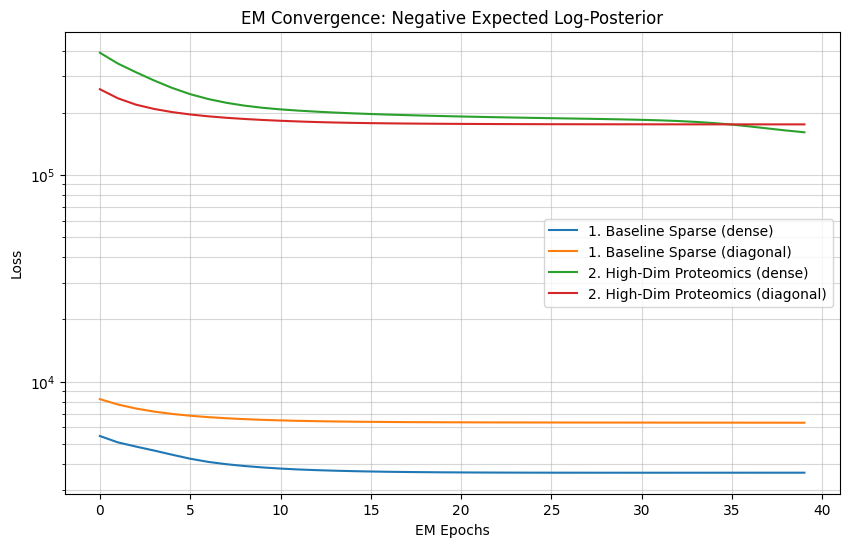

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

# ---------------------------------------------------------
# 1. Definitive Vectorized DFOULS Model
# ---------------------------------------------------------
class DFOULS_Definitive(nn.Module):
    def __init__(self, obs_dim, latent_dim, covar_dim, delta=1e-4, theta_mode="diagonal"):
        super().__init__()
        self.D = obs_dim
        self.K = latent_dim
        self.C_dim = covar_dim
        self.delta = delta
        self.theta_mode = theta_mode
        
        # 1. Continuous-Time Dynamics
        if self.theta_mode == "dense":
            self.L = nn.Parameter(torch.eye(self.K) + 0.1 * torch.randn(self.K, self.K))
            self.K_unconstrained = nn.Parameter(torch.randn(self.K, self.K) * 0.1)
        elif self.theta_mode == "diagonal":
            self.log_rho = nn.Parameter(torch.randn(self.K) * 0.1 - 2.0)
            
        # 2. Linear Mean Function
        self.B = nn.Parameter(torch.randn(self.K, self.C_dim) * 0.1)
        self.C_int = nn.Parameter(torch.randn(self.K, self.C_dim) * 0.1)
        self.d_bias = nn.Parameter(torch.randn(self.K) * 0.1)
        
        # 3. Factor Loadings (Reverted to nn.Parameter for gentle GEM optimization)
        self.Z = nn.Parameter(torch.randn(self.D, self.K) - 0.5) 
        self.register_buffer('tril_mask', torch.tril(torch.ones(self.D, self.K)))

    def get_theta(self):
        if self.theta_mode == "dense":
            L_tril = torch.tril(self.L)
            S = L_tril @ L_tril.T + self.delta * torch.eye(self.K, device=self.Z.device)
            return S + (self.K_unconstrained - self.K_unconstrained.T)
        return torch.diag(torch.exp(self.log_rho))

    def get_subject_matrices(self, Theta, u, times):
        dt = times[1:] - times[:-1]
        Theta_batch = Theta.unsqueeze(0).expand(times.shape[0]-1, self.K, self.K)
        A_trans = torch.linalg.matrix_exp(-Theta_batch * dt.view(-1, 1, 1))
        
        u_t, t_val = u[1:], times[1:].unsqueeze(1)
        mu = u_t @ self.B.T + (u_t * t_val) @ self.C_int.T + self.d_bias
        
        I_batch = torch.eye(self.K, device=self.Z.device).unsqueeze(0).expand(times.shape[0]-1, self.K, self.K)
        b_shift = torch.bmm(I_batch - A_trans, mu.unsqueeze(-1)).squeeze(-1)
        
        Lambda = self.tril_mask * torch.exp(self.Z)
        return A_trans, b_shift, dt, Lambda

    def kalman_smoother(self, x_obs, A_trans, b_shift, dt, Lambda):
        T = x_obs.shape[0]
        device = x_obs.device
        
        f_pred, P_pred = torch.zeros(T, self.K, device=device), torch.zeros(T, self.K, self.K, device=device)
        f_filt, P_filt = torch.zeros(T, self.K, device=device), torch.zeros(T, self.K, self.K, device=device)
        f_filt[0], P_filt[0] = torch.zeros(self.K, device=device), torch.eye(self.K, device=device)
        
        R_mat, I_k = torch.eye(self.D, device=device), torch.eye(self.K, device=device)
        
        for j in range(1, T):
            idx = j - 1
            f_pred[j] = A_trans[idx] @ f_filt[j-1] + b_shift[idx]
            P_pred[j] = A_trans[idx] @ P_filt[j-1] @ A_trans[idx].T + (dt[idx] * I_k)
            
            if torch.isnan(x_obs[j]).all():
                f_filt[j], P_filt[j] = f_pred[j], P_pred[j]
            else:
                x_pred = Lambda @ f_pred[j]
                S_t = Lambda @ P_pred[j] @ Lambda.T + R_mat
                K_gain = P_pred[j] @ Lambda.T @ torch.linalg.inv(S_t)
                f_filt[j] = f_pred[j] + K_gain @ (x_obs[j] - x_pred)
                P_filt[j] = (I_k - K_gain @ Lambda) @ P_pred[j]
            
        f_smooth, P_smooth, P_cross = torch.zeros_like(f_filt), torch.zeros_like(P_filt), torch.zeros_like(P_filt)
        f_smooth[-1], P_smooth[-1] = f_filt[-1], P_filt[-1]
        
        for j in range(T-2, -1, -1):
            J_t = P_filt[j] @ A_trans[j].T @ torch.linalg.inv(P_pred[j+1])
            f_smooth[j] = f_filt[j] + J_t @ (f_smooth[j+1] - f_pred[j+1])
            P_smooth[j] = P_filt[j] + J_t @ (P_smooth[j+1] - P_pred[j+1]) @ J_t.T
            P_cross[j+1] = J_t @ P_smooth[j+1]
            
        return f_smooth, P_smooth, P_cross

    def expected_complete_log_posterior_vectorized(self, subjects_data, smoothed_stats, Theta, Lambda):
        ll_obs, ll_lat = 0.0, 0.0
        LTL = Lambda.T @ Lambda 
        
        for i, subj in enumerate(subjects_data):
            x_obs, u, times = subj['x'], subj['u'], subj['t']
            f_s, P_s, P_c = smoothed_stats[i]
            A_trans, b_shift, dt, _ = self.get_subject_matrices(Theta, u, times)
            
            valid_mask = ~torch.isnan(x_obs).any(dim=1)
            if valid_mask.any():
                x_v, f_v, P_v = x_obs[valid_mask], f_s[valid_mask], P_s[valid_mask]
                trace_E = torch.sum(P_v * LTL, dim=(1,2)) + torch.sum(f_v * (f_v @ LTL), dim=1)
                term_obs = torch.sum(x_v**2, dim=1) - 2 * torch.sum(x_v * (f_v @ Lambda.T), dim=1) + trace_E
                ll_obs -= 0.5 * torch.sum(term_obs)
                
            f_j, f_jm1 = f_s[1:], f_s[:-1]
            P_j, P_jm1, P_cj = P_s[1:], P_s[:-1], P_c[1:]
            
            trace_Ej = torch.diagonal(P_j, dim1=-2, dim2=-1).sum(-1) + torch.sum(f_j**2, dim=1)
            AtA = torch.bmm(A_trans.transpose(1, 2), A_trans)
            trace_AEjm1A = torch.sum(P_jm1 * AtA, dim=(1,2)) + torch.sum(f_jm1 * torch.bmm(AtA, f_jm1.unsqueeze(-1)).squeeze(-1), dim=1)
            bb = torch.sum(b_shift**2, dim=1)
            
            trace_AEcross = torch.sum(P_cj * A_trans, dim=(1,2)) + torch.sum(f_j * torch.bmm(A_trans, f_jm1.unsqueeze(-1)).squeeze(-1), dim=1)
            b_f = torch.sum(b_shift * f_j, dim=1)
            A_fm1 = torch.bmm(A_trans, f_jm1.unsqueeze(-1)).squeeze(-1)
            b_A_fm1 = torch.sum(b_shift * A_fm1, dim=1)
            
            expected_residual = trace_Ej + trace_AEjm1A + bb - 2*trace_AEcross - 2*b_f + 2*b_A_fm1
            ll_lat += torch.sum(-0.5 * self.K * torch.log(dt) - 0.5 * (1/dt) * expected_residual)
            
        active_Z = self.Z[self.tril_mask == 1]
        log_prior_Z = -0.5 * torch.sum(active_Z ** 2)
        
        log_prior_dyn = -0.5 * torch.sum(self.log_rho ** 2) if self.theta_mode == "diagonal" else \
                        -0.5 * (torch.sum(torch.tril(self.L) ** 2) + torch.sum(self.K_unconstrained ** 2))
        log_prior_lin = -0.5 * (torch.sum(self.B**2) + torch.sum(self.C_int**2) + torch.sum(self.d_bias**2))
        
        return ll_obs + ll_lat + log_prior_Z + log_prior_dyn + log_prior_lin

    def pca_warm_start(self, subjects_data):
        with torch.no_grad():
            x_all = torch.cat([s['x'] for s in subjects_data], dim=0)
            x_valid = x_all[~torch.isnan(x_all).any(dim=1)] 
            U, S_vals, Vh = torch.linalg.svd(x_valid - x_valid.mean(dim=0), full_matrices=False)
            
            Lambda_pca = Vh[:self.K, :].T * torch.sqrt(S_vals[:self.K] / x_valid.shape[0])
            
            # Flawless LQ Decomposition to respect Lower-Triangular constraint
            q, r = torch.linalg.qr(Lambda_pca.T)
            Lambda_tril = r.T * torch.sign(torch.diag(r.T)).unsqueeze(0)
            
            mask = self.tril_mask == 1
            self.Z.data[mask] = torch.log(torch.abs(Lambda_tril[mask]) + 1e-4)
            self.B.data.fill_(0.0); self.C_int.data.fill_(0.0); self.d_bias.data.fill_(0.0)

    def fit_em(self, subjects_data, num_em_epochs=40, m_step_iters=20, lr=0.01):
        optimizer = optim.Adam(self.parameters(), lr=lr)
        epoch_losses = [] # To store the loss history
        
        for epoch in range(num_em_epochs):
            Theta, Lambda = self.get_theta(), self.tril_mask * torch.exp(self.Z)
            
            smoothed_stats = []
            with torch.no_grad():
                for subj in subjects_data:
                    A_trans, b_shift, dt, _ = self.get_subject_matrices(Theta, subj['u'], subj['t'])
                    smoothed_stats.append(self.kalman_smoother(subj['x'], A_trans, b_shift, dt, Lambda))
            
            # Inner M-step (Generalized EM)
            current_epoch_loss = 0.0
            for m in range(m_step_iters):
                optimizer.zero_grad()
                Theta_m, Lambda_m = self.get_theta(), self.tril_mask * torch.exp(self.Z)
                # We calculate the negative log-likelihood as our loss
                loss = -self.expected_complete_log_posterior_vectorized(subjects_data, smoothed_stats, Theta_m, Lambda_m)
                loss.backward()
                optimizer.step()
                current_epoch_loss = loss.item()
            
            epoch_losses.append(current_epoch_loss)
                
        return smoothed_stats, epoch_losses # Now returning losses

# ---------------------------------------------------------
# 2. Scaled Data Simulation
# ---------------------------------------------------------
def simulate_ad_cohort_stress(N, D, K, C_dim, theta_mode="dense", seed=42):
    torch.manual_seed(seed)
    
    if theta_mode == "diagonal":
        rho_true = torch.linspace(0.02, 0.15, K)
        Theta_true = torch.diag(rho_true)
    else:
        L_true = torch.tril(torch.randn(K, K) * 0.3 + torch.eye(K)*0.5)
        K_unc = torch.randn(K, K) * 0.2
        Theta_true = L_true @ L_true.T + 1e-4 * torch.eye(K) + K_unc - K_unc.T
        
    B_true, C_true, d_true = torch.randn(K, C_dim)*0.5, torch.randn(K, C_dim)*0.5, torch.randn(K)*0.5
    Z_true = torch.randn(D, K) - 1.0 
    Lambda_true = torch.tril(torch.ones(D, K)) * torch.exp(Z_true)
    
    subjects_data = []
    for _ in range(N):
        J_i = torch.randint(3, 6, (1,)).item()
        age_baseline = torch.rand(1) * 20 + 55
        dt = torch.rand(J_i - 1) * 3.5 + 1.5
        times = torch.cat([age_baseline, age_baseline + torch.cumsum(dt, dim=0)])
        
        # Crucial Time Scaling
        t_scaled = (times - 70.0) / 10.0 
        u = torch.randn(J_i, C_dim)
        
        F_true = torch.zeros(J_i, K)
        F_true[0] = torch.randn(K) * 0.1
        
        for j in range(1, J_i):
            delta_t = times[j] - times[j-1]
            A_ij = torch.linalg.matrix_exp(-Theta_true * delta_t)
            mu_j = B_true @ u[j] + C_true @ (u[j] * t_scaled[j]) + d_true
            F_true[j] = A_ij @ F_true[j-1] + ((torch.eye(K) - A_ij) @ mu_j) + (torch.randn(K) * torch.sqrt(delta_t))
            
        X_obs = F_true @ Lambda_true.T + torch.randn(J_i, D)
        subjects_data.append({'x': X_obs, 'u': u, 't': t_scaled, 'F_true': F_true})
        
    return subjects_data, {'Lambda': Lambda_true, 'Theta': Theta_true}

# ---------------------------------------------------------
# 3. Execution Wrapper
# ---------------------------------------------------------
def run_stress_test(n_runs=3):
    scenarios = [
        {"name": "1. Baseline Sparse",     "N": 50,  "D": 20,   "K": 3, "C": 2},
        {"name": "2. High-Dim Proteomics", "N": 100, "D": 200,  "K": 5, "C": 2},
    ]
    
    print(f"{'Scenario':<25} | {'Mode':<10} | {'Λ Corr (μ ± σ)':<15} | {'Avg Loss':<12} | {'Time (s)'}")
    print("-" * 90)
    
    plt.figure(figsize=(10, 6))
    
    for s in scenarios:
        for mode in ["dense", "diagonal"]:
            l_corrs, final_losses, run_times = [], [], []
            last_loss_history = []
            
            for run_idx in range(n_runs):
                subjects_data, true_params = simulate_ad_cohort_stress(
                    s["N"], s["D"], s["K"], s["C"], theta_mode=mode, seed=100+run_idx
                )
                
                start_time = time.time()
                model = DFOULS_Definitive(obs_dim=s["D"], latent_dim=s["K"], covar_dim=s["C"], theta_mode=mode)
                model.pca_warm_start(subjects_data)
                
                # Capture smoothed stats and the loss trajectory
                smoothed_stats, losses = model.fit_em(subjects_data, num_em_epochs=40)
                
                # Metrics logic
                with torch.no_grad():
                    Lambda_est = model.tril_mask * torch.exp(model.Z)
                    mask = model.tril_mask == 1
                    l_corr = np.corrcoef(true_params['Lambda'][mask].numpy(), Lambda_est[mask].numpy())[0, 1]
                
                l_corrs.append(l_corr)
                final_losses.append(losses[-1])
                run_times.append(time.time() - start_time)
                last_loss_history = losses # Keep the last run's history for plotting

            # Plotting the convergence of the last run for this scenario
            plt.plot(last_loss_history, label=f"{s['name']} ({mode})")
            
            print(f"{s['name']:<25} | {mode.capitalize():<10} | {np.mean(l_corrs):.3f} ± {np.std(l_corrs):.3f} | {np.mean(final_losses):.2e} | {np.mean(run_times):>8.1f}")

    plt.title("EM Convergence: Negative Expected Log-Posterior")
    plt.xlabel("EM Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.yscale('log') # Loss can span orders of magnitude
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

if __name__ == "__main__":
    # You can increase n_runs to 5 or 10 if you have access to a GPU or a high-thread CPU environment.
    run_stress_test(n_runs=3)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

# ---------------------------------------------------------
# 1. Definitive Vectorized DFOULS Model
# ---------------------------------------------------------
class DFOULS_Definitive(nn.Module):
    def __init__(self, obs_dim, latent_dim, covar_dim, delta=1e-4, theta_mode="diagonal"):
        super().__init__()
        self.D = obs_dim
        self.K = latent_dim
        self.C_dim = covar_dim
        self.delta = delta
        self.theta_mode = theta_mode
        
        # 1. Continuous-Time Dynamics
        if self.theta_mode == "dense":
            self.L = nn.Parameter(torch.eye(self.K) + 0.1 * torch.randn(self.K, self.K))
            self.K_unconstrained = nn.Parameter(torch.randn(self.K, self.K) * 0.1)
        elif self.theta_mode == "diagonal":
            self.log_rho = nn.Parameter(torch.randn(self.K) * 0.1 - 2.0)
            
        # 2. Linear Mean Function
        self.B = nn.Parameter(torch.randn(self.K, self.C_dim) * 0.1)
        self.C_int = nn.Parameter(torch.randn(self.K, self.C_dim) * 0.1)
        self.d_bias = nn.Parameter(torch.randn(self.K) * 0.1)
        
        # 3. Factor Loadings (Reverted to nn.Parameter for gentle GEM optimization)
        self.Z = nn.Parameter(torch.randn(self.D, self.K) - 0.5) 
        self.register_buffer('tril_mask', torch.tril(torch.ones(self.D, self.K)))

    def get_theta(self):
        if self.theta_mode == "dense":
            L_tril = torch.tril(self.L)
            S = L_tril @ L_tril.T + self.delta * torch.eye(self.K, device=self.Z.device)
            return S + (self.K_unconstrained - self.K_unconstrained.T)
        return torch.diag(torch.exp(self.log_rho))

    def get_subject_matrices(self, Theta, u, times):
        dt = times[1:] - times[:-1]
        Theta_batch = Theta.unsqueeze(0).expand(times.shape[0]-1, self.K, self.K)
        A_trans = torch.linalg.matrix_exp(-Theta_batch * dt.view(-1, 1, 1))
        
        u_t, t_val = u[1:], times[1:].unsqueeze(1)
        mu = u_t @ self.B.T + (u_t * t_val) @ self.C_int.T + self.d_bias
        
        I_batch = torch.eye(self.K, device=self.Z.device).unsqueeze(0).expand(times.shape[0]-1, self.K, self.K)
        b_shift = torch.bmm(I_batch - A_trans, mu.unsqueeze(-1)).squeeze(-1)
        
        Lambda = self.tril_mask * torch.exp(self.Z)
        return A_trans, b_shift, dt, Lambda

    def kalman_smoother(self, x_obs, A_trans, b_shift, dt, Lambda):
        T = x_obs.shape[0]
        device = x_obs.device
        
        f_pred, P_pred = torch.zeros(T, self.K, device=device), torch.zeros(T, self.K, self.K, device=device)
        f_filt, P_filt = torch.zeros(T, self.K, device=device), torch.zeros(T, self.K, self.K, device=device)
        f_filt[0], P_filt[0] = torch.zeros(self.K, device=device), torch.eye(self.K, device=device)
        
        R_mat, I_k = torch.eye(self.D, device=device), torch.eye(self.K, device=device)
        
        for j in range(1, T):
            idx = j - 1
            f_pred[j] = A_trans[idx] @ f_filt[j-1] + b_shift[idx]
            P_pred[j] = A_trans[idx] @ P_filt[j-1] @ A_trans[idx].T + (dt[idx] * I_k)
            
            if torch.isnan(x_obs[j]).all():
                f_filt[j], P_filt[j] = f_pred[j], P_pred[j]
            else:
                x_pred = Lambda @ f_pred[j]
                S_t = Lambda @ P_pred[j] @ Lambda.T + R_mat
                K_gain = P_pred[j] @ Lambda.T @ torch.linalg.inv(S_t)
                f_filt[j] = f_pred[j] + K_gain @ (x_obs[j] - x_pred)
                P_filt[j] = (I_k - K_gain @ Lambda) @ P_pred[j]
            
        f_smooth, P_smooth, P_cross = torch.zeros_like(f_filt), torch.zeros_like(P_filt), torch.zeros_like(P_filt)
        f_smooth[-1], P_smooth[-1] = f_filt[-1], P_filt[-1]
        
        for j in range(T-2, -1, -1):
            J_t = P_filt[j] @ A_trans[j].T @ torch.linalg.inv(P_pred[j+1])
            f_smooth[j] = f_filt[j] + J_t @ (f_smooth[j+1] - f_pred[j+1])
            P_smooth[j] = P_filt[j] + J_t @ (P_smooth[j+1] - P_pred[j+1]) @ J_t.T
            P_cross[j+1] = J_t @ P_smooth[j+1]
            
        return f_smooth, P_smooth, P_cross

    def expected_complete_log_posterior_vectorized(self, subjects_data, smoothed_stats, Theta, Lambda):
        ll_obs, ll_lat = 0.0, 0.0
        LTL = Lambda.T @ Lambda 
        
        for i, subj in enumerate(subjects_data):
            x_obs, u, times = subj['x'], subj['u'], subj['t']
            f_s, P_s, P_c = smoothed_stats[i]
            A_trans, b_shift, dt, _ = self.get_subject_matrices(Theta, u, times)
            
            valid_mask = ~torch.isnan(x_obs).any(dim=1)
            if valid_mask.any():
                x_v, f_v, P_v = x_obs[valid_mask], f_s[valid_mask], P_s[valid_mask]
                trace_E = torch.sum(P_v * LTL, dim=(1,2)) + torch.sum(f_v * (f_v @ LTL), dim=1)
                term_obs = torch.sum(x_v**2, dim=1) - 2 * torch.sum(x_v * (f_v @ Lambda.T), dim=1) + trace_E
                ll_obs -= 0.5 * torch.sum(term_obs)
                
            f_j, f_jm1 = f_s[1:], f_s[:-1]
            P_j, P_jm1, P_cj = P_s[1:], P_s[:-1], P_c[1:]
            
            trace_Ej = torch.diagonal(P_j, dim1=-2, dim2=-1).sum(-1) + torch.sum(f_j**2, dim=1)
            AtA = torch.bmm(A_trans.transpose(1, 2), A_trans)
            trace_AEjm1A = torch.sum(P_jm1 * AtA, dim=(1,2)) + torch.sum(f_jm1 * torch.bmm(AtA, f_jm1.unsqueeze(-1)).squeeze(-1), dim=1)
            bb = torch.sum(b_shift**2, dim=1)
            
            trace_AEcross = torch.sum(P_cj * A_trans, dim=(1,2)) + torch.sum(f_j * torch.bmm(A_trans, f_jm1.unsqueeze(-1)).squeeze(-1), dim=1)
            b_f = torch.sum(b_shift * f_j, dim=1)
            A_fm1 = torch.bmm(A_trans, f_jm1.unsqueeze(-1)).squeeze(-1)
            b_A_fm1 = torch.sum(b_shift * A_fm1, dim=1)
            
            expected_residual = trace_Ej + trace_AEjm1A + bb - 2*trace_AEcross - 2*b_f + 2*b_A_fm1
            ll_lat += torch.sum(-0.5 * self.K * torch.log(dt) - 0.5 * (1/dt) * expected_residual)
            
        active_Z = self.Z[self.tril_mask == 1]
        log_prior_Z = -0.5 * torch.sum(active_Z ** 2)
        
        log_prior_dyn = -0.5 * torch.sum(self.log_rho ** 2) if self.theta_mode == "diagonal" else \
                        -0.5 * (torch.sum(torch.tril(self.L) ** 2) + torch.sum(self.K_unconstrained ** 2))
        log_prior_lin = -0.5 * (torch.sum(self.B**2) + torch.sum(self.C_int**2) + torch.sum(self.d_bias**2))
        
        return ll_obs + ll_lat + log_prior_Z + log_prior_dyn + log_prior_lin

    def pca_warm_start(self, subjects_data):
        """Restored: Strict spatial initialization without noisy OLS temporal poisoning."""
        with torch.no_grad():
            x_all = torch.cat([s['x'] for s in subjects_data], dim=0)
            x_valid = x_all[~torch.isnan(x_all).any(dim=1)] 
            U, S_vals, Vh = torch.linalg.svd(x_valid - x_valid.mean(dim=0), full_matrices=False)
            
            Lambda_pca = Vh[:self.K, :].T * torch.sqrt(S_vals[:self.K] / x_valid.shape[0])
            
            # LQ Decomposition strictly mapping into Lower-Triangular space
            q, r = torch.linalg.qr(Lambda_pca.T)
            Lambda_tril = r.T * torch.sign(torch.diag(r.T)).unsqueeze(0)
            
            mask = self.tril_mask == 1
            self.Z.data[mask] = torch.log(torch.abs(Lambda_tril[mask]) + 1e-4)
            
            # Safe Zero-Initialization for covariates
            self.B.data.fill_(0.0)
            self.C_int.data.fill_(0.0)
            self.d_bias.data.fill_(0.0)

    def fit_em_multistart(self, subjects_data, num_em_epochs=40, m_step_iters=20, lr=0.01, n_starts=5, burn_in_epochs=10):
        """
        Executes Multi-Start GEM to guarantee the global optimum and eliminate variance.
        Runs short burn-in phases for different dynamic initializations, 
        selects the best, and trains to full convergence.
        """
        best_loss = float('inf')
        best_state_dict = None
        
        print(f"  Running {n_starts} Multi-Start Burn-ins ({burn_in_epochs} epochs each)...")
        
        for start in range(n_starts):
            # 1. Randomize Dynamic Parameters
            with torch.no_grad():
                if self.theta_mode == "dense":
                    nn.init.normal_(self.L, mean=0.0, std=0.1)
                    self.L.data += torch.eye(self.K, device=self.L.device)
                    nn.init.normal_(self.K_unconstrained, mean=0.0, std=0.1)
                else:
                    nn.init.normal_(self.log_rho, mean=-2.0, std=0.1)
                    
                nn.init.normal_(self.B, mean=0.0, std=0.1)
                nn.init.normal_(self.C_int, mean=0.0, std=0.1)
                nn.init.normal_(self.d_bias, mean=0.0, std=0.1)
            
            # 2. Re-anchor Spatial Parameters via PCA
            self.pca_warm_start(subjects_data)
            
            # 3. Burn-in Phase (Joint GEM Optimization)
            optimizer = optim.Adam(self.parameters(), lr=lr)
            start_loss = 0.0
            
            for epoch in range(burn_in_epochs):
                Theta, Lambda = self.get_theta(), self.tril_mask * torch.exp(self.Z)
                
                smoothed_stats = []
                with torch.no_grad():
                    for subj in subjects_data:
                        A_trans, b_shift, dt, _ = self.get_subject_matrices(Theta, subj['u'], subj['t'])
                        smoothed_stats.append(self.kalman_smoother(subj['x'], A_trans, b_shift, dt, Lambda))
                
                epoch_loss = 0.0
                for m in range(m_step_iters):
                    optimizer.zero_grad()
                    Theta_m, Lambda_m = self.get_theta(), self.tril_mask * torch.exp(self.Z)
                    loss = -self.expected_complete_log_posterior_vectorized(subjects_data, smoothed_stats, Theta_m, Lambda_m)
                    loss.backward()
                    optimizer.step()
                    epoch_loss += loss.item()
                start_loss = epoch_loss / m_step_iters
                
            # 4. Track the best performing initialization
            if start_loss < best_loss:
                best_loss = start_loss
                best_state_dict = {k: v.clone() for k, v in self.state_dict().items()}
                
        # 5. Load the winning initialization and finish training
        print(f"  Burn-in complete. Training best initialization for remaining {num_em_epochs - burn_in_epochs} epochs...")
        self.load_state_dict(best_state_dict)
        optimizer = optim.Adam(self.parameters(), lr=lr)
        
        for epoch in range(num_em_epochs - burn_in_epochs):
            Theta, Lambda = self.get_theta(), self.tril_mask * torch.exp(self.Z)
            
            smoothed_stats = []
            with torch.no_grad():
                for subj in subjects_data:
                    A_trans, b_shift, dt, _ = self.get_subject_matrices(Theta, subj['u'], subj['t'])
                    smoothed_stats.append(self.kalman_smoother(subj['x'], A_trans, b_shift, dt, Lambda))
            
            for m in range(m_step_iters):
                optimizer.zero_grad()
                Theta_m, Lambda_m = self.get_theta(), self.tril_mask * torch.exp(self.Z)
                loss = -self.expected_complete_log_posterior_vectorized(subjects_data, smoothed_stats, Theta_m, Lambda_m)
                loss.backward()
                optimizer.step()
                
        return smoothed_stats

    def fit_em(self, subjects_data, num_em_epochs=40, warmup_epochs=10, m_step_iters=20, lr=0.01):
        """
        Executes Staged Optimization to stabilize variance.
        Phase 1: Freeze Z (Lambda) and train only dynamics to align with PCA.
        Phase 2: Unfreeze Z and jointly fine-tune all parameters.
        """
        # Optimizer 1: Trains EVERYTHING EXCEPT Z (Lambda)
        dyn_params = [p for n, p in self.named_parameters() if n != 'Z']
        opt_dynamics_only = optim.Adam(dyn_params, lr=lr)
        
        # Optimizer 2: Trains ALL parameters jointly
        opt_joint = optim.Adam(self.parameters(), lr=lr)
        
        for epoch in range(num_em_epochs):
            Theta, Lambda = self.get_theta(), self.tril_mask * torch.exp(self.Z)
            
            # E-STEP
            smoothed_stats = []
            with torch.no_grad():
                for subj in subjects_data:
                    A_trans, b_shift, dt, _ = self.get_subject_matrices(Theta, subj['u'], subj['t'])
                    smoothed_stats.append(self.kalman_smoother(subj['x'], A_trans, b_shift, dt, Lambda))
            
            # Select the active optimizer based on the warmup phase
            active_optimizer = opt_dynamics_only if epoch < warmup_epochs else opt_joint
            
            # M-STEP
            for m in range(m_step_iters):
                active_optimizer.zero_grad()
                Theta_m, Lambda_m = self.get_theta(), self.tril_mask * torch.exp(self.Z)
                loss = -self.expected_complete_log_posterior_vectorized(subjects_data, smoothed_stats, Theta_m, Lambda_m)
                loss.backward()
                active_optimizer.step()
                
        return smoothed_stats

# ---------------------------------------------------------
# 2. Scaled Data Simulation
# ---------------------------------------------------------
def simulate_ad_cohort_stress(N, D, K, C_dim, theta_mode="dense", seed=42):
    torch.manual_seed(seed)
    
    if theta_mode == "diagonal":
        rho_true = torch.linspace(0.02, 0.15, K)
        Theta_true = torch.diag(rho_true)
    else:
        L_true = torch.tril(torch.randn(K, K) * 0.3 + torch.eye(K)*0.5)
        K_unc = torch.randn(K, K) * 0.2
        Theta_true = L_true @ L_true.T + 1e-4 * torch.eye(K) + K_unc - K_unc.T
        
    B_true, C_true, d_true = torch.randn(K, C_dim)*0.5, torch.randn(K, C_dim)*0.5, torch.randn(K)*0.5
    Z_true = torch.randn(D, K) - 1.0 
    Lambda_true = torch.tril(torch.ones(D, K)) * torch.exp(Z_true)
    
    subjects_data = []
    for _ in range(N):
        J_i = torch.randint(3, 6, (1,)).item()
        age_baseline = torch.rand(1) * 20 + 55
        dt = torch.rand(J_i - 1) * 3.5 + 1.5
        times = torch.cat([age_baseline, age_baseline + torch.cumsum(dt, dim=0)])
        
        # Crucial Time Scaling
        t_scaled = (times - 70.0) / 10.0 
        u = torch.randn(J_i, C_dim)
        
        F_true = torch.zeros(J_i, K)
        F_true[0] = torch.randn(K) * 0.1
        
        for j in range(1, J_i):
            delta_t = times[j] - times[j-1]
            A_ij = torch.linalg.matrix_exp(-Theta_true * delta_t)
            mu_j = B_true @ u[j] + C_true @ (u[j] * t_scaled[j]) + d_true
            F_true[j] = A_ij @ F_true[j-1] + ((torch.eye(K) - A_ij) @ mu_j) + (torch.randn(K) * torch.sqrt(delta_t))
            
        X_obs = F_true @ Lambda_true.T + torch.randn(J_i, D)
        subjects_data.append({'x': X_obs, 'u': u, 't': t_scaled, 'F_true': F_true})
        
    return subjects_data, {'Lambda': Lambda_true, 'Theta': Theta_true}

# ---------------------------------------------------------
# 3. Execution Wrapper
# ---------------------------------------------------------
def run_stress_test(n_runs=3):
    scenarios = [
        {"name": "1. Baseline Sparse",     "N": 50,  "D": 20,   "K": 3, "C": 2},
        {"name": "2. High-Dim Proteomics", "N": 100, "D": 200,  "K": 5, "C": 2},
        {"name": "3. Ultra High-Dim",      "N": 100, "D": 1000, "K": 5, "C": 2},
        {"name": "4. Complex Pathways",    "N": 100, "D": 50,   "K": 10,"C": 3},
        {"name": "5. Large Cohort",        "N": 500, "D": 50,   "K": 5, "C": 2}
    ]
    
    # Expand column widths to accommodate the "mean ± std" formatting
    print(f"{'Scenario':<25} | {'Mode':<10} | {'Λ Corr (μ ± σ)':<15} | {'F Corr (μ ± σ)':<15} | {'Θ Corr (μ ± σ)':<15} | {'Avg Time (s)'}")
    print("-" * 105)
    
    modes = ["dense", "diagonal"]
    
    for s in scenarios:
        for mode in modes:
            l_corrs = []
            f_corrs = []
            theta_corrs = []
            run_times = []
            
            for run_idx in range(n_runs):
                # Increment seed to generate a different clinical cohort for each run
                current_seed = 101 + run_idx
                subjects_data, true_params = simulate_ad_cohort_stress(
                    s["N"], s["D"], s["K"], s["C"], theta_mode=mode, seed=current_seed
                )
                
                start_time = time.time()
                
                model = DFOULS_Definitive(obs_dim=s["D"], latent_dim=s["K"], covar_dim=s["C"], theta_mode=mode)
                model.pca_warm_start(subjects_data)
                
                # Fit the model
                smoothed_stats = model.fit_em_multistart(subjects_data, num_em_epochs=40, m_step_iters=20, lr=0.01)
                
                # Evaluate metrics
                with torch.no_grad():
                    mask = model.tril_mask == 1
                    Lambda_est = model.tril_mask * torch.exp(model.Z)
                    Theta_est = model.get_theta()
                    
                    # Flatten latent states across all subjects
                    f_true_flat = torch.cat([subj['F_true'] for subj in subjects_data], dim=0).numpy().flatten()
                    f_est_flat = torch.cat([stat[0] for stat in smoothed_stats], dim=0).numpy().flatten()
                    
                    # Compute correlations for this run
                    f_corr = np.corrcoef(f_true_flat, f_est_flat)[0, 1]
                    l_corr = np.corrcoef(true_params['Lambda'][mask].numpy(), Lambda_est[mask].numpy())[0, 1]
                    
                    # Adaptive Theta correlation to prevent zero-inflation
                    if mode == "diagonal":
                        th_true = torch.diag(true_params['Theta']).numpy()
                        th_est = torch.diag(Theta_est).cpu().numpy()
                    else:
                        th_true = true_params['Theta'].numpy().flatten()
                        th_est = Theta_est.cpu().numpy().flatten()
                    theta_corr = np.corrcoef(th_true, th_est)[0, 1]
                
                elapsed = time.time() - start_time
                
                # Accumulate metrics
                l_corrs.append(l_corr)
                f_corrs.append(f_corr)
                theta_corrs.append(theta_corr)
                run_times.append(elapsed)
            
            # Calculate Mean and Standard Deviation across the runs
            l_mu, l_std = np.mean(l_corrs), np.std(l_corrs)
            f_mu, f_std = np.mean(f_corrs), np.std(f_corrs)
            th_mu, th_std = np.mean(theta_corrs), np.std(theta_corrs)
            time_avg = np.mean(run_times)
            
            # Format and print the consolidated results row
            l_str = f"{l_mu:.3f} ± {l_std:.3f}"
            f_str = f"{f_mu:.3f} ± {f_std:.3f}"
            th_str = f"{th_mu:.3f} ± {th_std:.3f}"
            
            print(f"{s['name']:<25} | {mode.capitalize():<10} | {l_str:<15} | {f_str:<15} | {th_str:<15} | {time_avg:>8.1f}")
        print("-" * 105)

if __name__ == "__main__":
    # You can increase n_runs to 5 or 10 if you have access to a GPU or a high-thread CPU environment.
    run_stress_test(n_runs=3)

Scenario                  | Mode       | Λ Corr (μ ± σ)  | F Corr (μ ± σ)  | Θ Corr (μ ± σ)  | Avg Time (s)
---------------------------------------------------------------------------------------------------------
  Running 5 Multi-Start Burn-ins (10 epochs each)...
  Burn-in complete. Training best initialization for remaining 30 epochs...
  Running 5 Multi-Start Burn-ins (10 epochs each)...
  Burn-in complete. Training best initialization for remaining 30 epochs...
  Running 5 Multi-Start Burn-ins (10 epochs each)...
  Burn-in complete. Training best initialization for remaining 30 epochs...
1. Baseline Sparse        | Dense      | 0.811 ± 0.176   | 0.698 ± 0.153   | 0.659 ± 0.290   |    269.8
  Running 5 Multi-Start Burn-ins (10 epochs each)...
  Burn-in complete. Training best initialization for remaining 30 epochs...
  Running 5 Multi-Start Burn-ins (10 epochs each)...
  Burn-in complete. Training best initialization for remaining 30 epochs...
  Running 5 Multi-Start Burn-ins (10 